# 03 - TCN WFO v1 Legit Both-Side TBM

Local TCN walk-forward experiment using a 3-class triple-barrier target.

Design goals:

- Keep the TBM neutral/no-hit state instead of dropping it.
- Train explicit `P(down)`, `P(neutral)`, and `P(up)` outputs.
- Make the primary strategy trade both directions, with minimum long and short participation.
- Select trading parameters on the validation window only.
- Score against same-bracket always-long and always-short baselines.
- Report execution stress so a result is not just a maker-fill artifact.
- Save artifacts directly to `artifacts/notebooks_v2/03_tcn` for the MAS notebooks.

The headline strategy is not allowed to become long-only. If the model cannot beat baseline while trading both sides, the notebook should show that plainly.


## 0 · Environment

In [15]:
import calendar, itertools, json, math, random, time, warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import QuantileTransformer
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("seaborn-whitegrid")
mpl.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 10, "axes.titlesize": 11, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
})
ACCENT = "#F7931A"; BLUE = "#2962FF"; GREY = "#9E9E9E"; RED = "#EF5350"; GREEN = "#26A69A"; PURPLE = "#7E57C2"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)


Device: mps


## 1 · Configuration

In [16]:
# -- Local data/artifacts ------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "hybrid-multi-agent-trading-system":
    for parent in Path.cwd().parents:
        if parent.name == "hybrid-multi-agent-trading-system":
            PROJECT_ROOT = parent
            break

DATA_PATH = PROJECT_ROOT / "data/features/BTCUSDT_1h_unified.parquet"
ARTS_DIR = PROJECT_ROOT / "artifacts/notebooks_v2/03_tcn"
ARTS_DIR.mkdir(parents=True, exist_ok=True)

# -- Split discipline ---------------------------------------------------------
GRID_VAL_START = pd.Timestamp("2023-06-01")
GRID_VAL_END = pd.Timestamp("2024-05-31 23:00:00")
OOS_START = pd.Timestamp("2024-06-01")
OOS_END = pd.Timestamp("2026-05-31 23:00:00")
WFO_START = GRID_VAL_START
RETRAIN_MONTHS = 3
WFO_SCHEME = "expanding"
TRAIN_WINDOW_MONTHS = 36
EMBARGO_H = 72                  # > TBM horizon + sequence overlap cushion
VAL_FRAC = 0.15

# -- TCN / label spec ---------------------------------------------------------
TBM_VOL_WINDOW = 24
TBM_MULT = 2.0
TBM_VERT_H = 24
FRAC_D = 0.4
FFD_THRES = 1e-4
SEQ_LEN = 48
TCN_CHANNELS = [64, 64, 64, 64]
TCN_KERNEL = 3
TCN_DROPOUT = 0.20
EPOCHS = 80
BATCH_SIZE = 256
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 10
LAMBDA_VOL = 0.35
AUX_FWD_H = 6
N_CLASSES = 3
CLASS_NAMES = {0: "down", 1: "neutral", 2: "up"}

# -- Execution model ----------------------------------------------------------
MAKER_FEE = 0.0
SPOT_TAKER_FEE = 0.0005
FUTURES_TAKER_FEE = 0.0005
BUFFER = 0.0005
SHORT_FUNDING_H = 0.0000077
MIN_SL = 0.010
ANN = np.sqrt(24 * 365)

# -- Selection constraints ----------------------------------------------------
PRIMARY_TRADE_DIRECTION = "both"
MIN_TRADES_GRID = 120
MAX_TRADES_GRID = 800
MIN_SIDE_RATIO = 0.20
MAX_GRID_DD = -0.40
TARGET_OOS_RETURN_WFEES = 0.20

# Same compact feature family as static 03_tcn_v1 for comparability.
LGBM_CORE = ["stoch_k_14", "ret_2h", "rsi_divergence", "close_vs_sma_7", "bear_streak",
             "close_vs_s1", "macd_hist_5_13", "ad_z_48h", "ret_3h"]
V1_EXTRA = ["ret_1h", "rsi_14", "vol_ratio_24h", "bb_position_20", "hour_sin", "hour_cos",
            "atr_14_pct", "hurst_168h", "trend_score", "close_vs_sma_50", "ma_bull_score"]
V4_FEATURES = ["close_vs_true_vwap", "hurst_24h", "hurst_72h", "tfi_pct", "tfi_z_24h",
               "bb_width_pct", "sideways_flag"]
STRUCT_FEATURES = ["liq_vwap_dev_24h", "volat_atr_20_pct", "mtf_alignment", "mtf_h4_rsi"]
BASE_FEATURES = LGBM_CORE + V1_EXTRA + V4_FEATURES + STRUCT_FEATURES
FFD_COL = "ffd_log_price"

TRADING_GRID = {
    "long_threshold": [0.38, 0.42, 0.46, 0.50, 0.55, 0.60],
    "short_threshold": [0.38, 0.42, 0.46, 0.50, 0.55, 0.60],
    "neutral_max": [0.40, 0.50, 0.60, 0.70],
    "edge_margin": [0.03, 0.06, 0.10, 0.15],
    "entry_atr_mult": [0.0, 0.3],
    "sl_atr_mult": [1.0, 1.5, 2.0],
    "tp_atr_mult": [1.5, 2.0, 2.5, 3.0],
    "min_hold": [6, 12],
    "max_hold": [24, 48, 72],
    "cooldown": [2, 6],
    "trade_direction": [PRIMARY_TRADE_DIRECTION],
}

print(f"Data -> {DATA_PATH}")
print(f"Artifacts -> {ARTS_DIR}")
print(f"WFO: {WFO_SCHEME}, step={RETRAIN_MONTHS}mo, grid-val={GRID_VAL_START.date()}->{GRID_VAL_END.date()}")
print(f"OOS: {OOS_START.date()}->{OOS_END.date()}")


Data -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/features/BTCUSDT_1h_unified.parquet
Artifacts -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/03_tcn
WFO: expanding, step=3mo, grid-val=2023-06-01->2024-05-31
OOS: 2024-06-01->2026-05-31


## 2 · Load Unified Parquet And Guards

In [17]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"{DATA_PATH} not found. Upload/copy BTCUSDT_1h_unified.parquet first.")

df = pd.read_parquet(DATA_PATH)
df.index = df.index.tz_localize(None) if getattr(df.index, "tz", None) else df.index
df = df.sort_index()

future_name_hits = [c for c in df.columns if any(tok in c.lower() for tok in [
    "future", "lead", "next_", "target", "label", "y_"
])]
print(f"Data: {df.shape[0]:,} bars x {df.shape[1]:,} cols | {df.index.min()} -> {df.index.max()}")
print("Future/label-name guard hits:", future_name_hits[:20], "| count:", len(future_name_hits))

missing = [f for f in BASE_FEATURES if f not in df.columns]
if missing:
    raise RuntimeError(f"Missing TCN features: {missing}")
print(f"Base features present: {len(BASE_FEATURES)}")


Data: 77,036 bars x 291 cols | 2017-08-17 04:00:00 -> 2026-05-31 23:00:00
Future/label-name guard hits: ['weekly_mom_accel', 'label', 'taker_buy_price', 'struct_body_ratio'] | count: 4
Base features present: 31


## 3 · Fractional Differentiation And TBM Labels

In [18]:
log_close = np.log(df["close"])

def _ffd_weights(d, thres=1e-4):
    w = [1.0]; k = 1
    while True:
        wk = -w[-1] * (d - k + 1) / k
        w.append(wk); k += 1
        if abs(wk) < thres:
            break
    return np.array(w[::-1])

def _ffd_series(series, d, thres=1e-4):
    w = _ffd_weights(d, thres)
    out = np.full(len(series), np.nan)
    vals = series.values
    for i in range(len(w) - 1, len(series)):
        out[i] = float(np.dot(w, vals[i - len(w) + 1:i + 1]))
    return pd.Series(out, index=series.index, name=FFD_COL)

df[FFD_COL] = _ffd_series(log_close, FRAC_D, FFD_THRES)
ALL_FEATURES = BASE_FEATURES + [FFD_COL]

log_rets = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()
close_vals = df["close"].values
high_vals = df["high"].values
low_vals = df["low"].values
vol_vals = rolling_vol.values
n = len(df)

# 3-class TBM target: 0=down barrier first, 1=vertical/ambiguous, 2=up barrier first.
y_tbm = np.full(n, np.nan, dtype=np.float32)
y_fwd_vol = np.full(n, np.nan, dtype=np.float32)

t0 = time.time()
for i in range(n):
    if np.isnan(vol_vals[i]) or vol_vals[i] == 0:
        continue
    sigma = vol_vals[i] * close_vals[i]
    up = close_vals[i] + TBM_MULT * sigma
    dn = close_vals[i] - TBM_MULT * sigma
    end_j = min(i + TBM_VERT_H, n - 1)
    label = 1
    for j in range(i + 1, end_j + 1):
        hit_up = high_vals[j] >= up
        hit_dn = low_vals[j] <= dn
        if hit_up and hit_dn:
            label = 1  # unknown intrabar order; keep it neutral instead of inventing direction
            break
        if hit_up:
            label = 2
            break
        if hit_dn:
            label = 0
            break
    y_tbm[i] = label
    fwd = log_rets.values[i + 1:i + 1 + AUX_FWD_H]
    if len(fwd):
        y_fwd_vol[i] = float(np.std(fwd))

df["y_tbm3"] = y_tbm
df["y_fwd_vol"] = y_fwd_vol
valid_dir = df["y_tbm3"].isin([0, 1, 2])
print(f"3-class TBM labels built in {time.time()-t0:.1f}s")
print(df.loc[valid_dir, "y_tbm3"].value_counts(normalize=True).sort_index().rename(CLASS_NAMES))


3-class TBM labels built in 0.5s
y_tbm3
down      0.4738
neutral   0.0550
up        0.4712
Name: proportion, dtype: float64


## 4 · Model Helpers

In [19]:
class CausalBlock(nn.Module):
    def __init__(self, in_c, out_c, kernel, dilation, dropout):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.Conv1d(in_c, out_c, kernel, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(out_c, out_c, kernel, dilation=dilation, padding=pad)
        self.skip = nn.Conv1d(in_c, out_c, 1) if in_c != out_c else None
        self.drop = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(out_c)
        self.norm2 = nn.LayerNorm(out_c)

    def forward(self, x):
        r = self.skip(x) if self.skip is not None else x
        y = self.conv1(x)[..., :x.shape[-1]]
        y = F.relu(self.norm1(y.transpose(1, 2)).transpose(1, 2))
        y = self.drop(y)
        y = self.conv2(y)[..., :x.shape[-1]]
        y = F.relu(self.norm2(y.transpose(1, 2)).transpose(1, 2))
        y = self.drop(y)
        return F.relu(y + r)

class TCNMultiTask(nn.Module):
    def __init__(self, n_feat, channels, kernel, dropout, n_classes=N_CLASSES):
        super().__init__()
        layers = []
        in_c = n_feat
        for i, out_c in enumerate(channels):
            layers.append(CausalBlock(in_c, out_c, kernel, 2 ** i, dropout))
            in_c = out_c
        self.tcn = nn.Sequential(*layers)
        self.cls_head = nn.Linear(channels[-1], n_classes)
        self.vol_head = nn.Linear(channels[-1], 1)

    def forward(self, x):
        h = self.tcn(x.transpose(1, 2))
        last = h[:, :, -1]
        return self.cls_head(last), self.vol_head(last).squeeze(-1)

def make_seqs(X, y, yv, seq_len=SEQ_LEN):
    Xs, Y, Yv = [], [], []
    for i in range(seq_len - 1, len(X)):
        if y[i] not in (0, 1, 2):
            continue
        Xs.append(X[i - seq_len + 1:i + 1])
        Y.append(int(y[i]))
        Yv.append(yv[i] if not np.isnan(yv[i]) else 0.0)
    if not Xs:
        return None
    return np.stack(Xs).astype(np.float32), np.array(Y, np.int64), np.array(Yv, np.float32)

def _predict_proba(model, X_np, batch=2048):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X_np), batch):
            xb = torch.from_numpy(X_np[s:s+batch]).to(DEVICE)
            logits, _ = model(xb)
            out.append(torch.softmax(logits, -1).cpu().numpy())
    return np.concatenate(out, axis=0)

def _fold_percentile_scores(raw_probs, val_ref):
    out = np.full_like(raw_probs, np.nan, dtype=np.float32)
    for c in range(raw_probs.shape[1]):
        ref = np.sort(np.asarray(val_ref[:, c])[np.isfinite(val_ref[:, c])])
        if len(ref):
            out[:, c] = np.searchsorted(ref, raw_probs[:, c], side="right") / len(ref)
    return out.astype(np.float32)

def train_fold(Xtr, ytr, ytr_v, Xvl, yvl, yvl_v):
    g = torch.Generator(); g.manual_seed(SEED)
    model = TCNMultiTask(len(ALL_FEATURES), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
    counts = np.bincount(ytr, minlength=N_CLASSES).astype(np.float32)
    weights = 1.0 / np.maximum(counts, 1.0)
    weights = weights / weights.sum() * N_CLASSES
    cls_crit = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))
    vol_crit = nn.MSELoss()
    train_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr), torch.from_numpy(ytr_v)),
                              BATCH_SIZE, shuffle=True, drop_last=True, generator=g)
    val_loader = DataLoader(TensorDataset(torch.from_numpy(Xvl), torch.from_numpy(yvl), torch.from_numpy(yvl_v)),
                            BATCH_SIZE, shuffle=False)
    opt = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, epochs=EPOCHS, steps_per_epoch=max(1, len(train_loader)))
    best, best_state, best_ep, best_auc = 1e9, None, 0, np.nan
    for ep in range(1, EPOCHS + 1):
        model.train()
        for xb, yb, yv in train_loader:
            xb, yb, yv = xb.to(DEVICE), yb.to(DEVICE), yv.to(DEVICE)
            opt.zero_grad()
            logits, vol = model(xb)
            loss = cls_crit(logits, yb) + LAMBDA_VOL * vol_crit(vol, yv)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
        model.eval(); vl, ps, ys = 0.0, [], []
        with torch.no_grad():
            for xb, yb, yv in val_loader:
                xb, yb, yv = xb.to(DEVICE), yb.to(DEVICE), yv.to(DEVICE)
                logits, vol = model(xb)
                vl += (cls_crit(logits, yb) + LAMBDA_VOL * vol_crit(vol, yv)).item()
                ps.append(torch.softmax(logits, -1).cpu().numpy())
                ys.append(yb.cpu().numpy())
        vl /= max(len(val_loader), 1)
        ycat = np.concatenate(ys); pcat = np.concatenate(ps)
        try:
            auc = roc_auc_score(ycat, pcat, multi_class="ovr", labels=[0, 1, 2])
        except Exception:
            auc = np.nan
        if vl < best:
            best, best_auc, best_ep = vl, auc, ep
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep - best_ep >= PATIENCE:
            break
    model.load_state_dict(best_state)
    return model, {"best_val_loss": float(best), "best_val_auc_ovr": float(best_auc),
                   "best_epoch": int(best_ep), "class_counts": counts.astype(int).tolist()}

N_FEATURES = len(ALL_FEATURES)
n_params = sum(p.numel() for p in TCNMultiTask(N_FEATURES, TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters())
rf = 1 + 2 * (TCN_KERNEL - 1) * sum(2 ** i for i in range(len(TCN_CHANNELS)))
print(f"TCN params={n_params:,}, features={N_FEATURES}, classes={N_CLASSES}, receptive_field={rf}")


TCN params=96,068, features=32, classes=3, receptive_field=61


## 5 · Walk-Forward Training

In [20]:
feat_ok = df[ALL_FEATURES].notna().all(axis=1)
probs_raw = np.full((len(df), N_CLASSES), np.nan, dtype=np.float32)
probs_score = np.full((len(df), N_CLASSES), np.nan, dtype=np.float32)
fold_log = []
last_model = None

anchors = []
d = WFO_START
while d <= OOS_END:
    anchors.append(d)
    d += pd.DateOffset(months=RETRAIN_MONTHS)

t_all = time.time()
for fi, start in enumerate(anchors, 1):
    end = min(start + pd.DateOffset(months=RETRAIN_MONTHS), OOS_END + pd.Timedelta(hours=1))
    if WFO_SCHEME == "expanding":
        tr_start = df.index.min()
    elif WFO_SCHEME == "sliding":
        tr_start = start - pd.DateOffset(months=TRAIN_WINDOW_MONTHS)
    else:
        raise ValueError(WFO_SCHEME)
    tr_end = start - pd.Timedelta(hours=EMBARGO_H)
    train_mask = (df.index >= tr_start) & (df.index < tr_end) & feat_ok & valid_dir
    train_df = df[train_mask].copy()
    if len(train_df) < 4000:
        print(f"[{fi:02d}] skip {start.date()} insufficient train rows={len(train_df)}")
        continue
    cut = int(len(train_df) * (1 - VAL_FRAC))
    tri, vli = train_df.index[:cut], train_df.index[cut:]
    qt = QuantileTransformer(output_distribution="normal", n_quantiles=min(1000, len(tri)), random_state=SEED)
    qt.fit(np.nan_to_num(df.loc[tri, ALL_FEATURES].values.astype(np.float32)))

    def seqs(idx):
        sub = df.loc[idx]
        X = qt.transform(np.nan_to_num(sub[ALL_FEATURES].values.astype(np.float32))).astype(np.float32)
        return make_seqs(X, sub["y_tbm3"].values, sub["y_fwd_vol"].values)

    s_tr, s_vl = seqs(tri), seqs(vli)
    if s_tr is None or s_vl is None or len(np.unique(s_tr[1])) < 2:
        print(f"[{fi:02d}] skip {start.date()} bad sequence/class coverage")
        continue
    model, meta = train_fold(*s_tr, *s_vl)
    last_model = model

    val_probs = _predict_proba(model, s_vl[0])
    pred_start = start - pd.Timedelta(hours=SEQ_LEN - 1)
    block = df[(df.index >= pred_start) & (df.index < end) & feat_ok].copy()
    Xb = qt.transform(np.nan_to_num(block[ALL_FEATURES].values.astype(np.float32))).astype(np.float32)
    Xo, bar_idx = [], []
    for i in range(SEQ_LEN - 1, len(Xb)):
        Xo.append(Xb[i - SEQ_LEN + 1:i + 1]); bar_idx.append(block.index[i])
    if not Xo:
        continue
    Xo = np.stack(Xo).astype(np.float32)
    pred_raw = _predict_proba(model, Xo)
    pred_score = _fold_percentile_scores(pred_raw, val_probs)
    pred_idx = pd.DatetimeIndex(bar_idx)
    keep = (pred_idx >= start) & (pred_idx < end)
    rows = df.index.get_indexer(pred_idx[keep])
    probs_raw[rows, :] = pred_raw[keep]
    probs_score[rows, :] = pred_score[keep]

    fold_log.append({"fold": fi, "start": str(start), "end": str(end),
                     "train_rows": int(len(train_df)), **meta})
    print(f"[{fi:02d}/{len(anchors)}] {start.date()}->{(end-pd.Timedelta(hours=1)).date()} "
          f"train={len(train_df):,} val_auc_ovr={meta['best_val_auc_ovr']:.3f} "
          f"best_ep={meta['best_epoch']} elapsed={(time.time()-t_all)/60:.1f}m", flush=True)

if last_model is not None:
    torch.save(last_model.state_dict(), ARTS_DIR / "model_lastfold.pt")

oos_m = (df.index >= OOS_START) & (df.index <= OOS_END) & np.isfinite(probs_raw).all(axis=1)
auc_m = oos_m & df["y_tbm3"].isin([0, 1, 2]).values
try:
    auc_oos_raw = roc_auc_score(df.loc[auc_m, "y_tbm3"].values.astype(int), probs_raw[auc_m], multi_class="ovr", labels=[0, 1, 2])
    auc_oos_score = roc_auc_score(df.loc[auc_m, "y_tbm3"].values.astype(int), probs_score[auc_m], multi_class="ovr", labels=[0, 1, 2])
except Exception:
    auc_oos_raw = np.nan
    auc_oos_score = np.nan
print(f"WFO done in {(time.time()-t_all)/60:.1f} min | folds={len(fold_log)}")
print(f"OOS AUC OVR raw={auc_oos_raw:.4f} | score={auc_oos_score:.4f} | OOS probs={oos_m.sum():,}")

oos_probs_raw_df = pd.DataFrame(probs_raw, index=df.index, columns=["p_down", "p_neutral", "p_up"])[(df.index >= OOS_START) & (df.index <= OOS_END)]
oos_probs_score_df = pd.DataFrame(probs_score, index=df.index, columns=["s_down", "s_neutral", "s_up"])[(df.index >= OOS_START) & (df.index <= OOS_END)]
wfo_probs_raw_df = pd.DataFrame(probs_raw, index=df.index, columns=["p_down", "p_neutral", "p_up"])
wfo_probs_score_df = pd.DataFrame(probs_score, index=df.index, columns=["s_down", "s_neutral", "s_up"])
oos_idx = oos_probs_raw_df.index
oos_df = df.loc[oos_idx].copy()


[01/12] 2023-06-01->2023-08-31 train=50,172 val_auc_ovr=0.534 best_ep=8 elapsed=0.5m
[02/12] 2023-09-01->2023-11-30 train=52,380 val_auc_ovr=0.549 best_ep=8 elapsed=1.0m
[03/12] 2023-12-01->2024-02-29 train=54,564 val_auc_ovr=0.577 best_ep=11 elapsed=1.6m
[04/12] 2024-03-01->2024-05-31 train=56,748 val_auc_ovr=0.594 best_ep=15 elapsed=2.3m
[05/12] 2024-06-01->2024-08-31 train=58,956 val_auc_ovr=0.581 best_ep=12 elapsed=3.0m
[06/12] 2024-09-01->2024-11-30 train=61,164 val_auc_ovr=0.601 best_ep=13 elapsed=3.7m
[07/12] 2024-12-01->2025-02-28 train=63,348 val_auc_ovr=0.595 best_ep=15 elapsed=4.5m
[08/12] 2025-03-01->2025-05-31 train=65,508 val_auc_ovr=0.581 best_ep=17 elapsed=5.4m
[09/12] 2025-06-01->2025-08-31 train=67,716 val_auc_ovr=0.570 best_ep=12 elapsed=6.2m
[10/12] 2025-09-01->2025-11-30 train=69,924 val_auc_ovr=0.556 best_ep=7 elapsed=6.8m
[11/12] 2025-12-01->2026-02-28 train=72,108 val_auc_ovr=0.563 best_ep=9 elapsed=7.5m
[12/12] 2026-03-01->2026-05-31 train=74,268 val_auc_ovr=0.

## 6 · Trading Grid Search On Validation Only

In [21]:
def _run_backtest(prob3, close, high, low, atr, *, long_threshold, short_threshold, neutral_max,
                  edge_margin, entry_atr_mult, sl_atr_mult, tp_atr_mult, min_hold, max_hold, cooldown,
                  trade_direction="both", with_fees=True, miss_unfilled=False, market_entry=False,
                  slippage_bps=0.0):
    n = len(close); eq = np.ones(n); cur = 1.0; trades = []
    in_pos = False; direction = None; entry_px = sl_px = tp_px = pos_eq = entry_fee = 0.0
    hold = cd = 0; funding = 0.0; pending = None
    exposure = np.zeros(n, dtype=bool)
    fills = {"maker_entry": 0, "taker_entry": 0, "missed_entry": 0}
    slip = slippage_bps / 10000.0

    for i in range(n):
        lo, hi, px = low[i], high[i], close[i]
        if in_pos:
            exposure[i] = True
            hold += 1
            if direction == "short":
                funding += SHORT_FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == "long" else 1 + (entry_px - px) / entry_px)
            ex, xpx, xf, reason = False, 0.0, 0.0, None
            if hold >= min_hold:
                if direction == "long":
                    if lo <= sl_px: xpx, ex, xf, reason = sl_px * (1 - slip), True, SPOT_TAKER_FEE if with_fees else 0.0, "sl"
                    elif hi >= tp_px: xpx, ex, xf, reason = tp_px, True, MAKER_FEE, "tp"
                    elif hold >= max_hold: xpx, ex, xf, reason = px * (1 - slip), True, SPOT_TAKER_FEE if with_fees else 0.0, "timeout"
                else:
                    if hi >= sl_px: xpx, ex, xf, reason = sl_px * (1 + slip), True, FUTURES_TAKER_FEE if with_fees else 0.0, "sl"
                    elif lo <= tp_px: xpx, ex, xf, reason = tp_px, True, MAKER_FEE, "tp"
                    elif hold >= max_hold: xpx, ex, xf, reason = px * (1 + slip), True, FUTURES_TAKER_FEE if with_fees else 0.0, "timeout"
            if ex:
                gross = ((xpx-entry_px)/entry_px if direction == "long" else (entry_px-xpx)/entry_px)
                net = gross - (entry_fee + xf if with_fees else 0.0) - funding
                cur = pos_eq * (1.0 + net); eq[i] = cur
                trades.append({"direction": direction, "reason": reason, "gross": gross, "net": net,
                               "hold": hold, "entry_fee": entry_fee, "exit_fee": xf, "funding": funding})
                in_pos, cd, funding = False, cooldown, 0.0
        elif pending is not None:
            d, lim, ps, pt = pending
            crossed = (lo <= lim + BUFFER) if d == "long" else (hi >= lim - BUFFER)
            if market_entry:
                crossed = False
            if crossed:
                entry = lim; ef = MAKER_FEE; fills["maker_entry"] += 1
            elif miss_unfilled:
                fills["missed_entry"] += 1
                pending = None; eq[i] = cur
                continue
            else:
                entry = px * (1 + slip if d == "long" else 1 - slip)
                ef = (SPOT_TAKER_FEE if d == "long" else FUTURES_TAKER_FEE) if with_fees else 0.0
                fills["taker_entry"] += 1
            entry_px, sl_px, tp_px, entry_fee = entry, ps, pt, ef
            direction, in_pos, pos_eq, hold, funding = d, True, cur, 0, 0.0
            pending = None; eq[i] = cur
        elif cd > 0:
            cd -= 1; eq[i] = cur
        elif i + 1 < n and np.isfinite(prob3[i]).all():
            p_down, p_neutral, p_up = prob3[i]
            a = max(atr[i], MIN_SL)
            long_ok = (p_up >= long_threshold) and ((p_up - p_down) >= edge_margin) and (p_neutral <= neutral_max)
            short_ok = (p_down >= short_threshold) and ((p_down - p_up) >= edge_margin) and (p_neutral <= neutral_max)
            if trade_direction in ("both", "long_only") and long_ok:
                pending = ("long", px*(1-entry_atr_mult*a), px*(1-sl_atr_mult*a), px*(1+tp_atr_mult*a))
            elif trade_direction in ("both", "short_only") and short_ok:
                pending = ("short", px*(1+entry_atr_mult*a), px*(1+sl_atr_mult*a), px*(1-tp_atr_mult*a))
            eq[i] = cur
        else:
            eq[i] = cur
    if in_pos:
        gross = ((px-entry_px)/entry_px if direction == "long" else (entry_px-px)/entry_px)
        taker = SPOT_TAKER_FEE if direction == "long" else FUTURES_TAKER_FEE
        net = gross - (entry_fee + (taker if with_fees else 0.0)) - funding
        cur = pos_eq * (1.0 + net); eq[-1] = cur
        trades.append({"direction": direction, "reason": "forced_end", "gross": gross, "net": net,
                       "hold": hold, "entry_fee": entry_fee, "exit_fee": taker if with_fees else 0.0,
                       "funding": funding})
    meta = {**fills, "exposure": float(exposure.mean())}
    return eq, pd.DataFrame(trades), meta

def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * ANN)

def _sortino(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    neg = r[r < 0]
    d = neg.std(ddof=1) if len(neg) > 1 else 1e-12
    return float(r.mean() / (d + 1e-12) * ANN)

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())

def _trade_metrics(t):
    if len(t) == 0:
        return {"n_trades": 0, "win_rate": 0.0, "avg_net": 0.0, "median_net": 0.0,
                "tp_rate": 0.0, "sl_rate": 0.0, "timeout_rate": 0.0}
    reasons = t["reason"].value_counts(normalize=True).to_dict()
    return {"n_trades": int(len(t)), "win_rate": float((t["net"] > 0).mean()),
            "avg_net": float(t["net"].mean()), "median_net": float(t["net"].median()),
            "tp_rate": float(reasons.get("tp", 0.0)), "sl_rate": float(reasons.get("sl", 0.0)),
            "timeout_rate": float(reasons.get("timeout", 0.0))}

def _bt_metrics(eq, t, meta=None):
    meta = meta or {}
    tm = _trade_metrics(t)
    nl = int((t["direction"] == "long").sum()) if len(t) else 0
    ns = int((t["direction"] == "short").sum()) if len(t) else 0
    return {"n_trades": tm["n_trades"], "n_long": nl, "n_short": ns,
            "win_rate": round(tm["win_rate"], 4), "avg_net": round(tm["avg_net"], 6),
            "median_net": round(tm["median_net"], 6), "tp_rate": round(tm["tp_rate"], 4),
            "sl_rate": round(tm["sl_rate"], 4), "timeout_rate": round(tm["timeout_rate"], 4),
            "total_ret": round(float(eq[-1]-1), 4), "sharpe": round(_sharpe(eq), 4),
            "sortino": round(_sortino(eq), 4), "maxdd": round(_maxdd(eq), 4),
            "exposure": round(float(meta.get("exposure", np.nan)), 4),
            "maker_entries": int(meta.get("maker_entry", 0)), "taker_entries": int(meta.get("taker_entry", 0)),
            "missed_entries": int(meta.get("missed_entry", 0))}

def _baseline_probs(kind, n):
    if kind == "long":
        return np.column_stack([np.zeros(n), np.zeros(n), np.ones(n)]).astype(float)
    if kind == "short":
        return np.column_stack([np.ones(n), np.zeros(n), np.zeros(n)]).astype(float)
    raise ValueError(kind)

def _baseline_for_direction(p, prob3, close, high, low, atr):
    candidates = []
    if p["trade_direction"] in ("both", "long_only"):
        eq, tr, meta = _run_backtest(_baseline_probs("long", len(prob3)), close, high, low, atr, with_fees=True, **p)
        candidates.append(("always_long", eq, tr, meta))
    if p["trade_direction"] in ("both", "short_only"):
        eq, tr, meta = _run_backtest(_baseline_probs("short", len(prob3)), close, high, low, atr, with_fees=True, **p)
        candidates.append(("always_short", eq, tr, meta))
    return max(candidates, key=lambda x: _sharpe(x[1]))

gv_m = (df.index >= GRID_VAL_START) & (df.index <= GRID_VAL_END)
gv_df = df[gv_m].copy()
gv_p = wfo_probs_raw_df.loc[gv_df.index].values
finite_ratio = np.isfinite(gv_p).all(axis=1).mean()
print(f"Grid-val finite probability ratio: {finite_ratio:.1%}")
if finite_ratio < 0.50:
    raise RuntimeError("Grid-val probabilities are too sparse. Check WFO fold generation.")

gv_close = gv_df["close"].values; gv_high = gv_df["high"].values; gv_low = gv_df["low"].values; gv_atr = gv_df["atr_14_pct"].values
rows = []
baseline_cache = {}
t0 = time.time()
for vals in itertools.product(*TRADING_GRID.values()):
    p = dict(zip(TRADING_GRID.keys(), vals))
    if p["max_hold"] < p["min_hold"]:
        continue
    eq, tr, meta = _run_backtest(gv_p, gv_close, gv_high, gv_low, gv_atr, with_fees=True, **p)
    ntr = len(tr)
    if not (MIN_TRADES_GRID <= ntr <= MAX_TRADES_GRID):
        continue
    nl = int((tr["direction"] == "long").sum()) if ntr else 0
    ns = int((tr["direction"] == "short").sum()) if ntr else 0
    if p["trade_direction"] == "both" and min(nl, ns) / max(ntr, 1) < MIN_SIDE_RATIO:
        continue
    if _maxdd(eq) < MAX_GRID_DD:
        continue

    base_key = tuple((k, p[k]) for k in sorted(p.keys()))
    if base_key not in baseline_cache:
        baseline_cache[base_key] = _baseline_for_direction(p, gv_p, gv_close, gv_high, gv_low, gv_atr)
    bname, beq, btr, bmeta = baseline_cache[base_key]

    ret = float(eq[-1]-1); base_ret = float(beq[-1]-1)
    sh = _sharpe(eq); base_sh = _sharpe(beq)
    rows.append({**p, "ret": ret, "sharpe": sh, "sortino": _sortino(eq), "maxdd": _maxdd(eq),
                 "n_trades": ntr, "n_long": nl, "n_short": ns,
                 "long_ratio": nl / ntr if ntr else 0.0, "short_ratio": ns / ntr if ntr else 0.0,
                 "win_rate": float((tr["net"] > 0).mean()) if ntr else 0.0,
                 "median_net": float(tr["net"].median()) if ntr else 0.0,
                 "baseline": bname, "baseline_ret": base_ret, "baseline_sharpe": base_sh,
                 "skill_ret_delta": ret - base_ret, "skill_sharpe_delta": sh - base_sh,
                 "baseline_trades": len(btr), "baseline_exposure": bmeta.get("exposure", np.nan)})

grid_df = pd.DataFrame(rows)
if grid_df.empty:
    raise RuntimeError("No valid both-side trading configs. Loosen TRADING_GRID or inspect probabilities.")
grid_df = grid_df.sort_values(["skill_sharpe_delta", "skill_ret_delta", "ret"], ascending=False).reset_index(drop=True)
grid_total_df = grid_df.sort_values(["sharpe", "ret"], ascending=False).reset_index(drop=True)

INT = {"min_hold", "max_hold", "cooldown"}
def _params_from_row(row):
    return {k: (int(row[k]) if k in INT else row[k] if k == "trade_direction" else float(row[k]))
            for k in ["long_threshold", "short_threshold", "neutral_max", "edge_margin", "entry_atr_mult",
                      "sl_atr_mult", "tp_atr_mult", "min_hold", "max_hold", "cooldown", "trade_direction"]}

BEST_SKILL = _params_from_row(grid_df.iloc[0])
BEST_TOTAL = _params_from_row(grid_total_df.iloc[0])
BEST = BEST_SKILL
SKILL_POSITIVE = bool(grid_df.iloc[0]["skill_sharpe_delta"] > 0 and grid_df.iloc[0]["skill_ret_delta"] > 0)
print(f"Grid done in {time.time()-t0:.0f}s | valid configs={len(grid_df):,} | baseline cache={len(baseline_cache):,}")
print("BEST_SKILL:", BEST_SKILL)
print("Skill-positive on grid-val:", SKILL_POSITIVE)
print("BEST_TOTAL for audit:", BEST_TOTAL)
display(grid_df.head(12))
display(grid_total_df.head(8))

Grid-val finite probability ratio: 100.0%
Grid done in 1629s | valid configs=54,862 | baseline cache=54,862
BEST_SKILL: {'long_threshold': 0.46, 'short_threshold': 0.5, 'neutral_max': 0.4, 'edge_margin': 0.1, 'entry_atr_mult': 0.0, 'sl_atr_mult': 1.0, 'tp_atr_mult': 2.0, 'min_hold': 6, 'max_hold': 24, 'cooldown': 6, 'trade_direction': 'both'}
Skill-positive on grid-val: True
BEST_TOTAL for audit: {'long_threshold': 0.46, 'short_threshold': 0.5, 'neutral_max': 0.4, 'edge_margin': 0.03, 'entry_atr_mult': 0.0, 'sl_atr_mult': 1.0, 'tp_atr_mult': 2.0, 'min_hold': 6, 'max_hold': 48, 'cooldown': 2, 'trade_direction': 'both'}


,long_threshold,short_threshold,neutral_max,edge_margin,entry_atr_mult,sl_atr_mult,tp_atr_mult,min_hold,max_hold,cooldown,...,short_ratio,win_rate,median_net,baseline,baseline_ret,baseline_sharpe,skill_ret_delta,skill_sharpe_delta,baseline_trades,baseline_exposure
0,0.4600,0.5000,0.4000,0.1000,0.0000,1.0000,2.0000,6,24,6,...,0.5032,0.4645,-0.0010,always_long,0.1164,0.3251,0.3996,1.5412,395,0.6409
1,0.4600,0.5000,0.5000,0.1000,0.0000,1.0000,2.0000,6,24,6,...,0.5032,0.4645,-0.0010,always_long,0.1164,0.3251,0.3996,1.5412,395,0.6409
2,0.4600,0.5000,0.6000,0.1000,0.0000,1.0000,2.0000,6,24,6,...,0.5032,0.4645,-0.0010,always_long,0.1164,0.3251,0.3996,1.5412,395,0.6409
3,0.4600,0.5000,0.7000,0.1000,0.0000,1.0000,2.0000,6,24,6,...,0.5032,0.4645,-0.0010,always_long,0.1164,0.3251,0.3996,1.5412,395,0.6409
4,0.5000,0.5000,0.4000,0.1000,0.0000,1.0000,2.0000,6,24,6,...,0.6328,0.4609,-0.0008,always_long,0.1164,0.3251,0.2769,1.3952,395,0.6409
5,0.5000,0.5000,0.5000,0.1000,0.0000,1.0000,2.0000,6,24,6,...,0.6328,0.4609,-0.0008,always_long,0.1164,0.3251,0.2769,1.3952,395,0.6409
6,0.5000,0.5000,0.6000,0.1000,0.0000,1.0000,2.0000,6,24,6,...,0.6328,0.4609,-0.0008,always_long,0.1164,0.3251,0.2769,1.3952,395,0.6409
7,0.5000,0.5000,0.7000,0.1000,0.0000,1.0000,2.0000,6,24,6,...,0.6328,0.4609,-0.0008,always_long,0.1164,0.3251,0.2769,1.3952,395,0.6409
8,0.4200,0.5000,0.4000,0.1000,0.0000,2.0000,2.5000,6,72,6,...,0.3307,0.5512,0.0097,always_long,0.2470,0.5894,0.5001,1.3769,224,0.7967
9,0.4200,0.5000,0.5000,0.1000,0.0000,2.0000,2.5000,6,72,6,...,0.3307,0.5512,0.0097,always_long,0.2470,0.5894,0.5001,1.3769,224,0.7967


,long_threshold,short_threshold,neutral_max,edge_margin,entry_atr_mult,sl_atr_mult,tp_atr_mult,min_hold,max_hold,cooldown,...,short_ratio,win_rate,median_net,baseline,baseline_ret,baseline_sharpe,skill_ret_delta,skill_sharpe_delta,baseline_trades,baseline_exposure
0,0.4600,0.5000,0.4000,0.0300,0.0000,1.0000,2.0000,6,48,2,...,0.3793,0.4655,-0.0105,always_long,1.9624,2.7800,-1.0818,-0.3400,420,0.8090
1,0.4600,0.5000,0.5000,0.0300,0.0000,1.0000,2.0000,6,48,2,...,0.3793,0.4655,-0.0105,always_long,1.9624,2.7800,-1.0818,-0.3400,420,0.8090
2,0.4600,0.5000,0.6000,0.0300,0.0000,1.0000,2.0000,6,48,2,...,0.3793,0.4655,-0.0105,always_long,1.9624,2.7800,-1.0818,-0.3400,420,0.8090
3,0.4600,0.5000,0.7000,0.0300,0.0000,1.0000,2.0000,6,48,2,...,0.3793,0.4655,-0.0105,always_long,1.9624,2.7800,-1.0818,-0.3400,420,0.8090
4,0.4600,0.5000,0.4000,0.0300,0.0000,1.0000,2.0000,6,72,2,...,0.3846,0.4497,-0.0105,always_long,1.6426,2.4978,-0.7963,-0.1484,393,0.8213
5,0.4600,0.5000,0.5000,0.0300,0.0000,1.0000,2.0000,6,72,2,...,0.3846,0.4497,-0.0105,always_long,1.6426,2.4978,-0.7963,-0.1484,393,0.8213
6,0.4600,0.5000,0.6000,0.0300,0.0000,1.0000,2.0000,6,72,2,...,0.3846,0.4497,-0.0105,always_long,1.6426,2.4978,-0.7963,-0.1484,393,0.8213
7,0.4600,0.5000,0.7000,0.0300,0.0000,1.0000,2.0000,6,72,2,...,0.3846,0.4497,-0.0105,always_long,1.6426,2.4978,-0.7963,-0.1484,393,0.8213


## 7 · OOS Backtest And Figures

,label,total_ret,sharpe,sortino,maxdd,n_trades,n_long,n_short,win_rate,avg_net,median_net,tp_rate,sl_rate,timeout_rate,exposure,maker_entries,taker_entries,missed_entries
0,TCN 3-class both-side w/fees,0.3643,0.5759,0.4545,-0.2072,456,216,240,0.4232,0.0008,-0.0105,0.2851,0.5175,0.1974,0.3410,454,2,0
1,TCN 3-class both-side 0fee,0.6093,0.8836,0.6988,-0.1906,456,216,240,0.4276,0.0011,-0.0100,0.2851,0.5175,0.1974,0.3410,454,2,0
2,Always-long same bracket,0.9040,0.9132,0.9789,-0.2341,825,825,0,0.4145,0.0009,-0.0105,0.2752,0.5297,0.1939,0.6236,821,4,0
3,Always-short same bracket,-0.2850,-0.4584,-0.4744,-0.6227,839,0,839,0.3802,-0.0003,-0.0105,0.2622,0.5507,0.1859,0.6172,836,3,0
4,TCN miss-unfilled,0.3675,0.5802,0.4575,-0.2072,456,216,240,0.4211,0.0008,-0.0105,0.2851,0.5175,0.1974,0.3405,456,0,2
5,TCN market+taker+0bp,0.0270,0.0517,0.0410,-0.3204,456,216,240,0.4123,0.0001,-0.0037,0.2851,0.5175,0.1974,0.3410,0,456,0
6,TCN market+taker+3bp,-0.1884,-0.4042,-0.3200,-0.3983,456,216,240,0.4057,-0.0004,-0.0042,0.2851,0.5175,0.1974,0.3410,0,456,0
7,TCN market+taker+5bp,-0.3063,-0.7071,-0.5585,-0.4587,456,216,240,0.4035,-0.0007,-0.0046,0.2851,0.5175,0.1974,0.3410,0,456,0
8,TCN market+taker+10bp,-0.5316,-1.4590,-1.1465,-0.5846,456,216,240,0.3904,-0.0016,-0.0056,0.2851,0.5175,0.1974,0.3410,0,456,0
9,TCN raw-total-selected audit,1.4840,1.4899,1.4013,-0.2199,532,312,220,0.4248,0.0018,-0.0105,0.3816,0.5620,0.0545,0.4608,531,1,0


Skill delta vs Always-long same bracket: ret=-54.0%, sharpe=-0.337
Target +20% with fees met: True


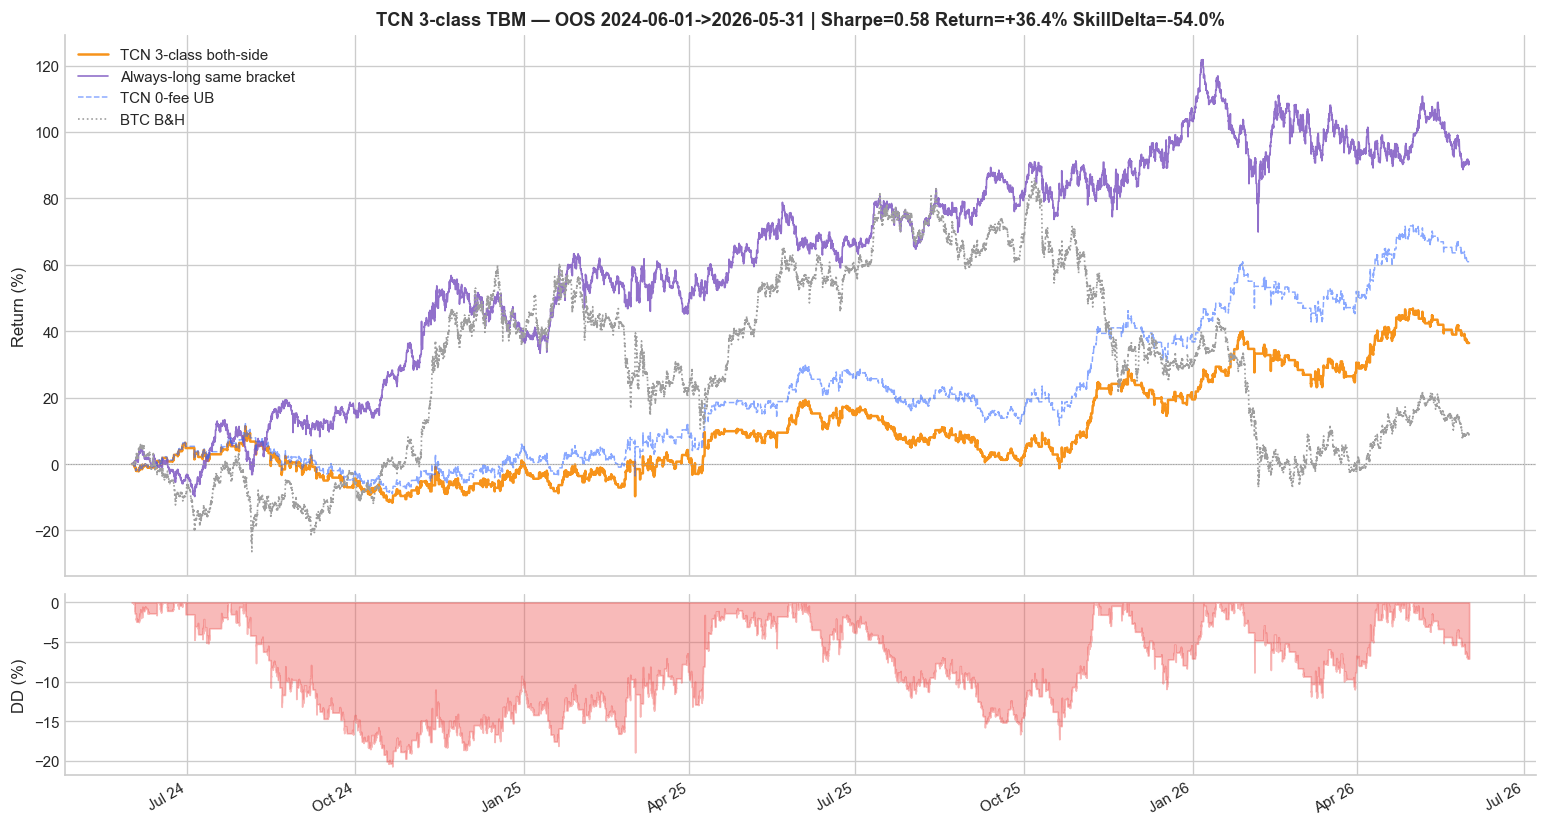

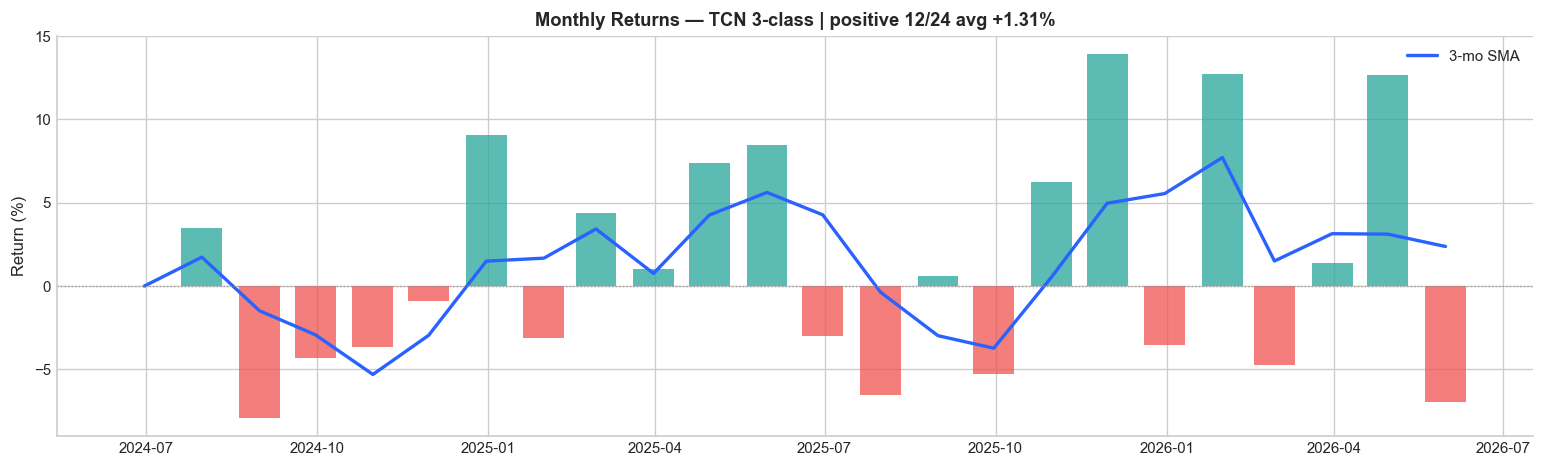

In [22]:
o_p = oos_probs_raw_df.values
o_idx = oos_probs_raw_df.index
o_df = df.loc[o_idx].copy()
o_close = o_df["close"].values; o_high = o_df["high"].values; o_low = o_df["low"].values; o_atr = o_df["atr_14_pct"].values

def _eval_config(label, prob3, params, with_fees=True, **exec_kwargs):
    eq, tr, meta = _run_backtest(prob3, o_close, o_high, o_low, o_atr, with_fees=with_fees, **exec_kwargs, **params)
    return {"label": label, "eq": eq, "trades": tr if len(tr) else pd.DataFrame(columns=["direction", "reason", "gross", "net", "hold"]),
            "meta": meta, "metrics": _bt_metrics(eq, tr, meta)}

def _matching_baseline_runs(params):
    runs = []
    if params["trade_direction"] in ("both", "long_only"):
        runs.append(_eval_config("Always-long same bracket", _baseline_probs("long", len(o_p)), params, True))
    if params["trade_direction"] in ("both", "short_only"):
        runs.append(_eval_config("Always-short same bracket", _baseline_probs("short", len(o_p)), params, True))
    return runs

RUNS = []
RUNS.append(_eval_config("TCN 3-class both-side w/fees", o_p, BEST, True))
RUNS.append(_eval_config("TCN 3-class both-side 0fee", o_p, BEST, False))
BASELINE_RUNS = _matching_baseline_runs(BEST)
RUNS.extend(BASELINE_RUNS)
RUNS.append(_eval_config("TCN miss-unfilled", o_p, BEST, True, miss_unfilled=True))
for bps in [0, 3, 5, 10]:
    RUNS.append(_eval_config(f"TCN market+taker+{bps}bp", o_p, BEST, True, market_entry=True, slippage_bps=bps))

RUNS.append(_eval_config("TCN raw-total-selected audit", o_p, BEST_TOTAL, True))
RAW_BASELINE_RUNS = _matching_baseline_runs(BEST_TOTAL)
for r in RAW_BASELINE_RUNS:
    r = dict(r)
    r["label"] = r["label"].replace("same bracket", "raw-total bracket")
    RUNS.append(r)

metrics_df = pd.DataFrame([{**r["metrics"], "label": r["label"]} for r in RUNS])
cols = ["label", "total_ret", "sharpe", "sortino", "maxdd", "n_trades", "n_long", "n_short", "win_rate",
        "avg_net", "median_net", "tp_rate", "sl_rate", "timeout_rate", "exposure", "maker_entries", "taker_entries", "missed_entries"]
display(metrics_df[cols])

PRIMARY = RUNS[0]
eq_fees, TF = PRIMARY["eq"], PRIMARY["trades"]
eq_0fee, T0 = RUNS[1]["eq"], RUNS[1]["trades"]
best_baseline = max(BASELINE_RUNS, key=lambda r: r["metrics"]["sharpe"])
skill_delta_ret = float(eq_fees[-1] - best_baseline["eq"][-1])
skill_delta_sharpe = float(_sharpe(eq_fees) - _sharpe(best_baseline["eq"]))
TARGET_MET = bool((eq_fees[-1] - 1) >= TARGET_OOS_RETURN_WFEES)
print(f"Skill delta vs {best_baseline['label']}: ret={skill_delta_ret:+.1%}, sharpe={skill_delta_sharpe:+.3f}")
print(f"Target +{TARGET_OOS_RETURN_WFEES:.0%} with fees met: {TARGET_MET}")

bh = (o_close / o_close[0] - 1) * 100
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[3, 1], sharex=True)
ax1.plot(o_idx, (eq_fees - 1) * 100, color=ACCENT, lw=1.5, label="TCN 3-class both-side")
ax1.plot(o_idx, (best_baseline["eq"] - 1) * 100, color=PURPLE, lw=1.0, alpha=0.85, label=best_baseline["label"])
ax1.plot(o_idx, (eq_0fee - 1) * 100, color=BLUE, lw=0.9, ls="--", alpha=0.55, label="TCN 0-fee UB")
ax1.plot(o_idx, bh, color=GREY, lw=1.0, ls=":", label="BTC B&H")
ax1.axhline(0, color=GREY, lw=0.6, ls=":")
ax1.set_ylabel("Return (%)"); ax1.legend()
ax1.set_title(f"TCN 3-class TBM — OOS {OOS_START.date()}->{o_idx[-1].date()} | "
              f"Sharpe={_sharpe(eq_fees):.2f} Return={eq_fees[-1]-1:+.1%} "
              f"SkillDelta={skill_delta_ret:+.1%}", fontweight="bold")
pk = np.maximum.accumulate(eq_fees); dd = (eq_fees - pk) / pk * 100
ax2.fill_between(o_idx, dd, 0, color=RED, alpha=0.4)
ax2.set_ylabel("DD (%)")
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
fig.tight_layout(); fig.savefig(ARTS_DIR / "01_equity_drawdown.png"); plt.show()

eqs = pd.Series(eq_fees, index=o_idx)
mret = eqs.resample("ME").last().pct_change().fillna(0) * 100
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(mret.index, mret.values, color=[GREEN if r >= 0 else RED for r in mret], width=22, alpha=0.75)
ax.plot(mret.index, mret.rolling(3, min_periods=1).mean(), color=BLUE, lw=2, label="3-mo SMA")
ax.axhline(0, color=GREY, lw=0.8, ls=":")
ax.set_ylabel("Return (%)"); ax.legend()
ax.set_title(f"Monthly Returns — TCN 3-class | positive {int((mret>0).sum())}/{len(mret)} avg {mret.mean():+.2f}%", fontweight="bold")
fig.tight_layout(); fig.savefig(ARTS_DIR / "02_monthly_returns.png"); plt.show()


## 8 · Robustness Checks

In [23]:
REGIME_DATES = {
    "chop": (pd.Timestamp("2024-06-01"), pd.Timestamp("2024-11-05")),
    "bull": (pd.Timestamp("2024-11-06"), pd.Timestamp("2025-10-31")),
    "bear": (pd.Timestamp("2025-11-01"), pd.Timestamp("2026-05-31 23:00:00")),
}

print("=== Regime breakdown: TCN vs selected same-bracket baseline ===")
reg_rows = []
for reg, (s, e) in REGIME_DATES.items():
    m = (o_idx >= s) & (o_idx <= e)
    if m.sum() > 24:
        seg = eq_fees[m] / eq_fees[m][0]
        bseg = best_baseline["eq"][m] / best_baseline["eq"][m][0]
        bhseg = o_close[m] / o_close[m][0]
        reg_rows.append({"regime": reg, "tcn_ret": seg[-1] - 1, "base_ret": bseg[-1] - 1,
                         "skill_delta": seg[-1] - bseg[-1], "bh_ret": bhseg[-1] - 1,
                         "tcn_sharpe": _sharpe(seg), "tcn_maxdd": _maxdd(seg)})
regime_df = pd.DataFrame(reg_rows)
display(regime_df)

print("=== Delay robustness ===")
delay_rows = []
for lag in [0, 1, 2, 6, 24]:
    p_lag = pd.DataFrame(o_p, index=o_idx, columns=["p_down", "p_neutral", "p_up"]).shift(lag).values
    eq, tr, meta = _run_backtest(p_lag, o_close, o_high, o_low, o_atr, with_fees=True, **BEST)
    delay_rows.append({"lag_h": lag, "ret": eq[-1] - 1, "sharpe": _sharpe(eq),
                       "maxdd": _maxdd(eq), "trades": len(tr), "exposure": meta["exposure"]})
delay_df = pd.DataFrame(delay_rows)
display(delay_df)

print("=== Directional contribution ===")
side_rows = []
for side in ["long_only", "short_only", "both"]:
    p_side = {**BEST, "trade_direction": side}
    eq, tr, meta = _run_backtest(o_p, o_close, o_high, o_low, o_atr, with_fees=True, **p_side)
    side_rows.append({"side": side, **_bt_metrics(eq, tr, meta)})
side_df = pd.DataFrame(side_rows)
display(side_df)

print("=== Exposure-matched random-entry null ===")
rng = np.random.default_rng(SEED)
n_sims = 300
n = len(o_p)
n_tr = len(TF)
rets = []
for _ in range(n_sims):
    s = np.full((n, 3), [0.0, 1.0, 0.0], dtype=float)
    locs = rng.choice(n, size=min(max(n_tr, 2), n), replace=False)
    dirs = rng.choice(["long", "short"], size=len(locs))
    for loc, d in zip(locs, dirs):
        s[loc] = [0.0, 0.0, 1.0] if d == "long" else [1.0, 0.0, 0.0]
    eq, _, _ = _run_backtest(s, o_close, o_high, o_low, o_atr, with_fees=True, **BEST)
    rets.append(eq[-1] - 1)
rets = np.array(rets)
real = eq_fees[-1] - 1
random_null = {"real_ret": real, "null_p50": float(np.percentile(rets, 50)),
               "null_p95": float(np.percentile(rets, 95)), "pctile": float((rets < real).mean())}
print(random_null)


=== Regime breakdown: TCN vs selected same-bracket baseline ===


,regime,tcn_ret,base_ret,skill_delta,bh_ret,tcn_sharpe,tcn_maxdd
0,chop,-0.0712,0.3075,-0.3787,0.0055,-0.7065,-0.2072
1,bull,0.1475,0.3488,-0.2013,0.5376,0.4734,-0.1729
2,bear,0.2541,0.0108,0.2433,-0.3286,1.6349,-0.1205


=== Delay robustness ===


,lag_h,ret,sharpe,maxdd,trades,exposure
0,0,0.3643,0.5759,-0.2072,456,0.3410
1,1,0.1014,0.1823,-0.2440,451,0.3479
2,2,0.0562,0.1011,-0.2919,453,0.3490
3,6,0.0098,0.0191,-0.3524,465,0.3537
4,24,0.2287,0.3747,-0.1922,454,0.3457


=== Directional contribution ===


,side,n_trades,n_long,n_short,win_rate,avg_net,median_net,tp_rate,sl_rate,timeout_rate,total_ret,sharpe,sortino,maxdd,exposure,maker_entries,taker_entries,missed_entries
0,long_only,257,257,0,0.4358,0.0012,-0.0105,0.2879,0.5097,0.2023,0.3367,0.7026,0.3965,-0.1407,0.1892,256,1,0
1,short_only,289,0,289,0.4221,0.0008,-0.0105,0.2872,0.5052,0.2076,0.2118,0.4217,0.2756,-0.1875,0.2234,288,1,0
2,both,456,216,240,0.4232,0.0008,-0.0105,0.2851,0.5175,0.1974,0.3643,0.5759,0.4545,-0.2072,0.3410,454,2,0


=== Exposure-matched random-entry null ===
{'real_ret': np.float64(0.3643269200802066), 'null_p50': 0.11734731594866898, 'null_p95': 0.6465011914045823, 'pctile': 0.8066666666666666}


## 9 · Save Local Artifacts

In [24]:
# Legacy MAS-compatible arrays: p_up and p_down remain the expected file names.
np.save(ARTS_DIR / "oos_probs.npy", oos_probs_raw_df["p_up"].values.astype(np.float32))
np.save(ARTS_DIR / "oos_pdown.npy", oos_probs_raw_df["p_down"].values.astype(np.float32))
np.save(ARTS_DIR / "oos_pneutral.npy", oos_probs_raw_df["p_neutral"].values.astype(np.float32))
np.save(ARTS_DIR / "oos_probs_raw.npy", oos_probs_raw_df["p_up"].values.astype(np.float32))
np.save(ARTS_DIR / "oos_pdown_raw.npy", oos_probs_raw_df["p_down"].values.astype(np.float32))
np.save(ARTS_DIR / "oos_pneutral_raw.npy", oos_probs_raw_df["p_neutral"].values.astype(np.float32))
np.save(ARTS_DIR / "oos_probs_3class.npy", oos_probs_raw_df[["p_down", "p_neutral", "p_up"]].values.astype(np.float32))
np.save(ARTS_DIR / "oos_scores_3class.npy", oos_probs_score_df[["s_down", "s_neutral", "s_up"]].values.astype(np.float32))
np.save(ARTS_DIR / "oos_index.npy", oos_probs_raw_df.index.astype("datetime64[ns]").astype(np.int64).values)

np.save(ARTS_DIR / "wfo_probs.npy", wfo_probs_raw_df["p_up"].values.astype(np.float32))
np.save(ARTS_DIR / "wfo_pdown.npy", wfo_probs_raw_df["p_down"].values.astype(np.float32))
np.save(ARTS_DIR / "wfo_pneutral.npy", wfo_probs_raw_df["p_neutral"].values.astype(np.float32))
np.save(ARTS_DIR / "wfo_probs_raw.npy", wfo_probs_raw_df["p_up"].values.astype(np.float32))
np.save(ARTS_DIR / "wfo_pdown_raw.npy", wfo_probs_raw_df["p_down"].values.astype(np.float32))
np.save(ARTS_DIR / "wfo_pneutral_raw.npy", wfo_probs_raw_df["p_neutral"].values.astype(np.float32))
np.save(ARTS_DIR / "wfo_probs_3class.npy", wfo_probs_raw_df[["p_down", "p_neutral", "p_up"]].values.astype(np.float32))
np.save(ARTS_DIR / "wfo_scores_3class.npy", wfo_probs_score_df[["s_down", "s_neutral", "s_up"]].values.astype(np.float32))
np.save(ARTS_DIR / "wfo_index.npy", wfo_probs_raw_df.index.astype("datetime64[ns]").astype(np.int64).values)

grid_df.head(300).to_csv(ARTS_DIR / "trading_grid_leaderboard.csv", index=False)
grid_total_df.head(300).to_csv(ARTS_DIR / "trading_grid_total_return_audit.csv", index=False)
metrics_df.to_csv(ARTS_DIR / "oos_robustness_metrics.csv", index=False)
regime_df.to_csv(ARTS_DIR / "regime_breakdown.csv", index=False)
delay_df.to_csv(ARTS_DIR / "delay_robustness.csv", index=False)
side_df.to_csv(ARTS_DIR / "directional_contribution.csv", index=False)

results = {
    "notebook": "03_tcn_v1_3class_tbm",
    "created": pd.Timestamp.now().isoformat(),
    "model": "TCNMultiTask WFO 3-class TBM (down / neutral / up + forward-vol)",
    "selection": "Primary grid constrained to trade both directions; selected by skill_sharpe_delta and skill_ret_delta over same-bracket always-long/always-short baselines; OOS held out.",
    "target_oos_return_wfees": TARGET_OOS_RETURN_WFEES,
    "target_oos_return_wfees_met": TARGET_MET,
    "skill_positive_on_grid_validation": SKILL_POSITIVE,
    "splits": {"grid_val_start": str(GRID_VAL_START.date()), "grid_val_end": str(GRID_VAL_END.date()),
               "oos_start": str(OOS_START.date()), "oos_end": str(OOS_END)},
    "wfo": {"scheme": WFO_SCHEME, "wfo_start": str(WFO_START.date()),
            "retrain_months": RETRAIN_MONTHS, "embargo_h": EMBARGO_H, "folds": fold_log},
    "tbm": {"type": "3class_high_low", "class_names": CLASS_NAMES, "mult": TBM_MULT,
            "vol_window": TBM_VOL_WINDOW, "vert_h": TBM_VERT_H,
            "ambiguous_same_bar_policy": "neutral"},
    "architecture": {"channels": TCN_CHANNELS, "kernel": TCN_KERNEL, "dropout": TCN_DROPOUT,
                     "seq_len": SEQ_LEN, "n_features": N_FEATURES, "n_params": n_params,
                     "receptive_field": rf, "n_classes": N_CLASSES},
    "training": {"epochs": EPOCHS, "patience": PATIENCE, "lambda_vol": LAMBDA_VOL},
    "oos_auc_tbm3_raw_ovr": round(float(auc_oos_raw), 4),
    "oos_auc_tbm3_score_ovr": round(float(auc_oos_score), 4),
    "all_features": ALL_FEATURES,
    "best_params_skill_selected": BEST_SKILL,
    "best_params_raw_total_audit": BEST_TOTAL,
    "grid_validation_best_skill_row": {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
                                       for k, v in grid_df.iloc[0].to_dict().items()},
    "backtest_wfees": _bt_metrics(eq_fees, TF, PRIMARY["meta"]),
    "backtest_0fee": _bt_metrics(eq_0fee, T0, RUNS[1]["meta"]),
    "same_bracket_baselines": {
        r["label"]: r["metrics"] for r in BASELINE_RUNS
    } | {
        "selected_baseline": best_baseline["label"],
        "skill_delta_vs_selected_baseline": {"ret": round(skill_delta_ret, 4), "sharpe": round(skill_delta_sharpe, 4)},
    },
    "execution_stress": {r["label"]: r["metrics"] for r in RUNS if "market+taker" in r["label"] or "miss-unfilled" in r["label"]},
    "raw_total_audit": {
        "tcn_raw_total_selected": next(r for r in RUNS if r["label"] == "TCN raw-total-selected audit")["metrics"],
        "matching_baselines": {r["label"]: r["metrics"] for r in RUNS if "raw-total bracket" in r["label"]},
    },
    "directional_contribution": side_df.to_dict(orient="records"),
    "random_entry_null": random_null,
    "monthly": {"mean_pct": round(float(mret.mean()), 3),
                "positive_months": int((mret > 0).sum()), "total_months": int(len(mret))},
    "artifacts": {"oos_probs": "oos_probs.npy", "oos_pdown": "oos_pdown.npy", "oos_pneutral": "oos_pneutral.npy",
                  "oos_probs_3class": "oos_probs_3class.npy", "oos_index": "oos_index.npy (int64 ns)",
                  "wfo_probs": "wfo_probs.npy", "wfo_pdown": "wfo_pdown.npy", "wfo_pneutral": "wfo_pneutral.npy",
                  "wfo_probs_3class": "wfo_probs_3class.npy", "model": "model_lastfold.pt",
                  "skill_grid": "trading_grid_leaderboard.csv", "raw_total_grid_audit": "trading_grid_total_return_audit.csv",
                  "robustness_metrics": "oos_robustness_metrics.csv"},
}
json.dump(results, open(ARTS_DIR / "results.json", "w"), indent=2, default=float)
print(json.dumps({k: v for k, v in results.items() if k not in ("all_features", "wfo")}, indent=2)[:3500])
print(f"Artifacts saved -> {ARTS_DIR}")


{
  "notebook": "03_tcn_v1_3class_tbm",
  "created": "2026-06-21T20:22:10.890536",
  "model": "TCNMultiTask WFO 3-class TBM (down / neutral / up + forward-vol)",
  "selection": "Primary grid constrained to trade both directions; selected by skill_sharpe_delta and skill_ret_delta over same-bracket always-long/always-short baselines; OOS held out.",
  "target_oos_return_wfees": 0.2,
  "target_oos_return_wfees_met": true,
  "skill_positive_on_grid_validation": true,
  "splits": {
    "grid_val_start": "2023-06-01",
    "grid_val_end": "2024-05-31",
    "oos_start": "2024-06-01",
    "oos_end": "2026-05-31 23:00:00"
  },
  "tbm": {
    "type": "3class_high_low",
    "class_names": {
      "0": "down",
      "1": "neutral",
      "2": "up"
    },
    "mult": 2.0,
    "vol_window": 24,
    "vert_h": 24,
    "ambiguous_same_bar_policy": "neutral"
  },
  "architecture": {
    "channels": [
      64,
      64,
      64,
      64
    ],
    "kernel": 3,
    "dropout": 0.2,
    "seq_len": 48,
   